# DPCCA: сравнение CPU и CUDA (CuPy)

Для каждой длины создаются несколько связанных сигналов, после чего один и тот же набор
данных обрабатывается на CPU и CUDA. Сравниваются:

- время полного вызова `dpcca`;
- матрицы ковариации `F`;
- матрицы корреляции `R`;
- матрицы частной корреляции `P`.

In [1]:
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cupy as cp
from scipy import stats

current_dir = Path.cwd().resolve()
project_dir = None
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "StatTools").exists():
        project_dir = candidate
        break

if project_dir is None:
    raise RuntimeError("Не удалось найти корень проекта с папкой StatTools")

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from StatTools.analysis.dpcca import dpcca

print("Project:", project_dir)
print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)


Project: D:\Python\FluctuationAnalysisTools
NumPy: 2.5.3
CuPy: 14.2.0


## Параметры эксперимента

In [2]:
SIZES = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
N_SIGNALS = 3
REPEATS = 15
PD = 2
STEP = 0.5
N_INTEGRAL = 1
BASE_S_VALUES = [16, 32, 64, 128, 256, 512]
RTOL = 1e-7
ATOL = 1e-10

print("Sizes:", SIZES)
print("Signals:", N_SIGNALS)
print("Repeats:", REPEATS)

Sizes: [1000, 10000, 100000, 1000000, 10000000, 100000000]
Signals: 3
Repeats: 15


## Генерация нескольких входных сигналов

Первый случайный ряд используется как общая компонента. К нему добавляется независимый шум.

In [3]:
def make_signals(length, n_signals, rng):
    common = rng.standard_normal(length)
    signals = []

    for _ in range(n_signals):
        noise = rng.standard_normal(length)
        signals.append(0.7 * common + 0.3 * noise)

    return np.vstack(signals)


def scales_for_length(length):
    return [s for s in BASE_S_VALUES if s < length]

example = make_signals(1024, N_SIGNALS, np.random.default_rng(42))
print("Input shape:", example.shape)

Input shape: (3, 1024)


## Измерение времени

Измеряется полный вызов DFA, включая передачу данных CPU–GPU.

In [4]:
def measure_dpcca(data, backend, s_values):
    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    start = perf_counter()
    p, r, f, used_s = dpcca(
        data,
        pd=PD,
        step=STEP,
        s=s_values,
        n_integral=N_INTEGRAL,
        processes=1,
        backend=backend,
    )

    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    elapsed = perf_counter() - start
    return elapsed, p, r, f, used_s

## Параметры


In [5]:
gpu_name = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

parameters = {
    "sizes": SIZES,
    "n_signals": N_SIGNALS,
    "repeats": REPEATS,
    "pd": PD,
    "step": STEP,
    "n_integral": N_INTEGRAL,
    "base_s_values": BASE_S_VALUES,
    "rtol": RTOL,
    "atol": ATOL,
    "processes": 1,
    "signal": "correlated Gaussian time series",
    "dtype": "float64",
    "gpu": gpu_name,
    "python": sys.version,
    "numpy": np.__version__,
    "cupy": cp.__version__,
}

print("GPU:", gpu_name)
display(pd.Series(parameters, name="value").to_frame())


GPU: NVIDIA GeForce RTX 5080


,value
sizes,"[1000, 10000, 100000, 1000000, 10000000, 10000..."
n_signals,3
repeats,15
pd,2
step,0.5
n_integral,1
base_s_values,"[16, 32, 64, 128, 256, 512]"
rtol,0.0
atol,0.0
processes,1


## Запуск эксперимента и результаты

Для каждой длины создаётся один набор из нескольких сигналов.
Перед серией измерений оба backend прогреваются один раз.

In [6]:
rng = np.random.default_rng(42)

signals = {}
dpcca_results = {}
records = []

for length in SIZES:
    data = make_signals(length, N_SIGNALS, rng)
    signals[length] = data
    s_values = scales_for_length(length)

    print(f"\nLength = {length}, shape = {data.shape}, S = {s_values}")

    measure_dpcca(data, "cpu", s_values)
    measure_dpcca(data, "cuda", s_values)

    for repeat in range(1, REPEATS + 1):
        cpu_time, p_cpu, r_cpu, f_cpu, s_cpu = measure_dpcca(
            data, "cpu", s_values
        )
        cuda_time, p_cuda, r_cuda, f_cuda, s_cuda = measure_dpcca(
            data, "cuda", s_values
        )

        np.testing.assert_array_equal(np.asarray(s_cuda), np.asarray(s_cpu))
        np.testing.assert_allclose(f_cuda, f_cpu, rtol=RTOL, atol=ATOL)
        np.testing.assert_allclose(r_cuda, r_cpu, rtol=RTOL, atol=ATOL)
        np.testing.assert_allclose(p_cuda, p_cpu, rtol=RTOL, atol=ATOL)

        dpcca_results[(length, repeat)] = {
            "s_cpu": np.asarray(s_cpu),
            "p_cpu": p_cpu,
            "r_cpu": r_cpu,
            "f_cpu": f_cpu,
            "s_cuda": np.asarray(s_cuda),
            "p_cuda": p_cuda,
            "r_cuda": r_cuda,
            "f_cuda": f_cuda,
        }

        records.append({
            "length": length,
            "n_signals": N_SIGNALS,
            "repeat": repeat,
            "cpu_seconds": cpu_time,
            "cuda_seconds": cuda_time,
            "speedup": cpu_time / cuda_time,
            "max_abs_diff_F": float(np.max(np.abs(f_cuda - f_cpu))),
            "max_abs_diff_R": float(np.max(np.abs(r_cuda - r_cpu))),
            "max_abs_diff_P": float(np.max(np.abs(p_cuda - p_cpu))),
        })

        print(
            f"  repeat {repeat}: CPU={cpu_time:.4f}s, "
            f"CUDA={cuda_time:.4f}s, speedup={cpu_time / cuda_time:.2f}x"
        )

results = pd.DataFrame(records)
display(results)



Length = 1000, shape = (3, 1000), S = [16, 32, 64, 128, 256, 512]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 1: CPU=0.0011s, CUDA=0.0182s, speedup=0.06x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 2: CPU=0.0009s, CUDA=0.0177s, speedup=0.05x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 3: CPU=0.0010s, CUDA=0.0177s, speedup=0.05x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 4: CPU=0.0009s, CUDA=0.0199s, speedup=0.04x
	DPCAA warning: only 

,length,n_signals,repeat,cpu_seconds,cuda_seconds,speedup,max_abs_diff_F,max_abs_diff_R,max_abs_diff_P
0,1000,3,1,0.001121,0.018201,0.061607,1.332268e-15,2.220446e-16,1.110223e-15
1,1000,3,2,0.000888,0.017688,0.050175,1.332268e-15,2.220446e-16,1.110223e-15
2,1000,3,3,0.000956,0.017721,0.053936,1.332268e-15,2.220446e-16,1.110223e-15
3,1000,3,4,0.000866,0.019890,0.043520,1.332268e-15,2.220446e-16,1.110223e-15
4,1000,3,5,0.000887,0.019099,0.046442,1.332268e-15,2.220446e-16,1.110223e-15
...,...,...,...,...,...,...,...,...,...
85,100000000,3,11,80.286433,45.838556,1.751504,1.953993e-14,4.440892e-16,1.276756e-15
86,100000000,3,12,79.929613,45.608610,1.752512,1.953993e-14,4.440892e-16,1.276756e-15
87,100000000,3,13,79.622210,45.865315,1.736000,1.953993e-14,4.440892e-16,1.276756e-15
88,100000000,3,14,80.109184,46.185695,1.734502,1.953993e-14,4.440892e-16,1.276756e-15


## Сводные результаты

`speedup > 1` означает, что CUDA быстрее CPU.

In [7]:
times = results.melt(
    id_vars=["length", "n_signals", "repeat"],
    value_vars=["cpu_seconds", "cuda_seconds"],
    var_name="backend",
    value_name="seconds",
)
times["backend"] = times["backend"].map({
    "cpu_seconds": "CPU",
    "cuda_seconds": "CUDA",
})

time_summary = times.groupby(["length", "backend"])["seconds"].agg(
    ["count", "mean", "median", "std", "min", "max"],
)
comparison = results.groupby("length").agg(
    median_speedup=("speedup", "median"),
    max_abs_diff_F=("max_abs_diff_F", "max"),
    max_abs_diff_R=("max_abs_diff_R", "max"),
    max_abs_diff_P=("max_abs_diff_P", "max"),
)

display(time_summary)
display(comparison)


count       mean     median       std        min        max
length    backend                                                             
1000      CPU         15   0.000939   0.000926  0.000060   0.000866   0.001121
          CUDA        15   0.019817   0.019010  0.003669   0.017267   0.032694
10000     CPU         15   0.004916   0.004860  0.000482   0.004370   0.005955
          CUDA        15   0.025468   0.025073  0.000963   0.024592   0.027861
100000    CPU         15   0.094422   0.093002  0.005900   0.087237   0.108483
          CUDA        15   0.028154   0.026875  0.003589   0.025837   0.040224
1000000   CPU         15   0.808557   0.808636  0.012419   0.787183   0.830152
          CUDA        15   0.050489   0.038556  0.031548   0.036308   0.129814
10000000  CPU         15   7.989744   7.967760  0.048460   7.940700   8.094680
          CUDA        15   0.448790   0.447079  0.060595   0.371260   0.608209
100000000 CPU         15  79.990505  79.929613  0.465687  78.845281  80.926147
          CUDA        15  45.742395  45.758680  0.180342  45.482734  46.185695

,median_speedup,max_abs_diff_F,max_abs_diff_R,max_abs_diff_P
length,,,,
1000,0.048378,1.332268e-15,2.220446e-16,1.110223e-15
10000,0.187787,1.065814e-14,4.440892e-16,2.553513e-15
100000,3.439019,1.243450e-14,4.440892e-16,2.275957e-15
1000000,20.805854,1.953993e-14,3.330669e-16,1.609823e-15
10000000,17.851437,5.329071e-15,4.440892e-16,1.665335e-15
100000000,1.751504,1.953993e-14,4.440892e-16,1.276756e-15


## Статистическое сравнение


In [8]:
test_records = []

for length, group in results.groupby("length"):
    difference = group["cpu_seconds"] - group["cuda_seconds"]
    shapiro_p = np.nan
    ttest_p = np.nan

    if len(group) >= 3 and np.std(difference) > 0:
        shapiro_p = stats.shapiro(difference).pvalue

    if len(group) >= 2 and np.std(difference) > 0:
        ttest_p = stats.ttest_rel(
            group["cpu_seconds"],
            group["cuda_seconds"],
        ).pvalue

    test_records.append({
        "length": length,
        "pairs": len(group),
        "mean_difference": difference.mean(),
        "shapiro_p": shapiro_p,
        "ttest_p": ttest_p,
    })

test_results = pd.DataFrame(test_records)
display(test_results)


,length,pairs,mean_difference,shapiro_p,ttest_p
0,1000,15,-0.018879,0.000005,1.095102e-11
1,10000,15,-0.020552,0.240467,1.524520e-20
2,100000,15,0.066268,0.370645,1.062045e-15
3,1000000,15,0.758068,0.002907,7.010163e-22
4,10000000,15,7.540953,0.147022,4.119283e-30
5,100000000,15,34.248110,0.934879,2.212794e-27


## Графики времени и ускорения

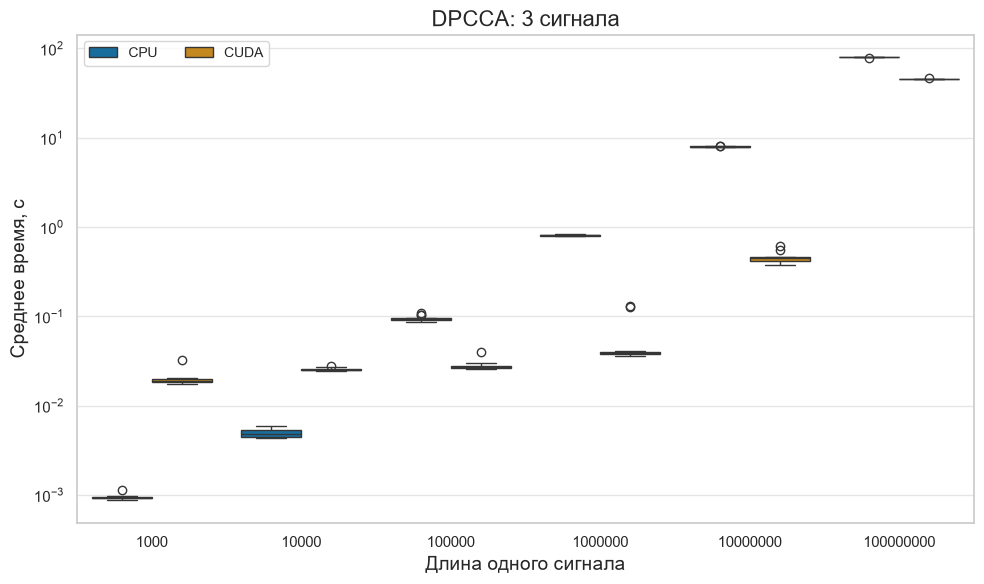

In [9]:
sns.set_theme(style="whitegrid", palette="colorblind")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=times,
    x="length",
    y="seconds",
    hue="backend",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Длина одного сигнала", fontsize=14)
ax.set_ylabel("Среднее время, с", fontsize=14)
ax.set_title(f"DPCCA: {N_SIGNALS} сигнала", fontsize=16)
ax.legend(title=None, loc="upper left", ncol=2, fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)


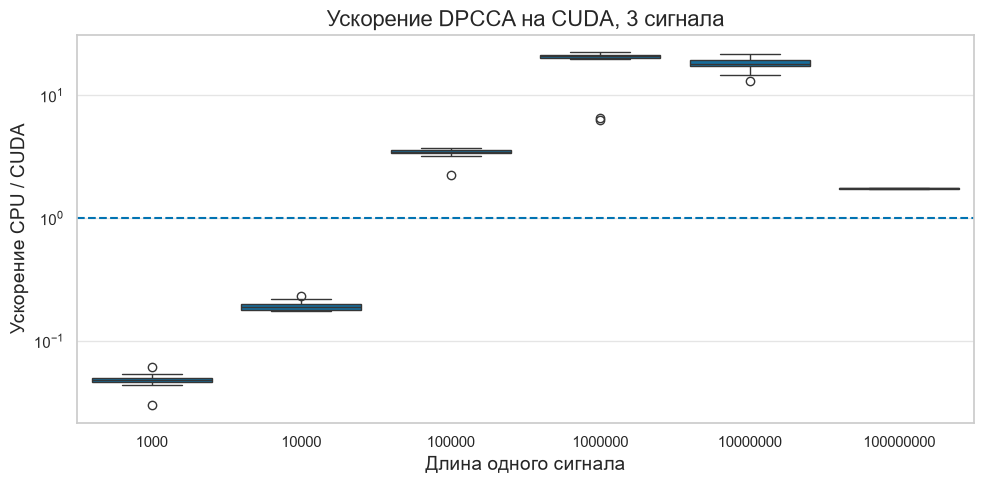

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=results,
    x="length",
    y="speedup",
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Длина одного сигнала", fontsize=14)
ax.set_ylabel("Ускорение CPU / CUDA", fontsize=14)
ax.set_title(f"Ускорение DPCCA на CUDA, {N_SIGNALS} сигнала", fontsize=16)
ax.axhline(1.0, linestyle="--")
fig.tight_layout()
plt.show()
plt.close(fig)
